<a href="https://colab.research.google.com/github/Ayman-Ewas/Supervised-Assignment-2-CNN-/blob/main/20230081_20230717_2023_CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning Course Assignment 2

| Name | ID |
|------|----|
|  Mohamed Beshr Al Sofi | 20230717  |
|  Ayman Sayed Abd-Elmonem | 20230081  |


In [30]:
# ── Setup & Data Loading ──────────────────────────────────────────────────
# Import required libraries and load the CIFAR-10 dataset.
# The dataset is split into 40 000 training, 10 000 validation,
# and 10 000 test images (32×32 RGB).

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [31]:
# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':      120,
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


In [32]:
# ── Helper Functions ──────────────────────────────────────────────────────
# train_and_evaluate() compiles, trains, and evaluates a Keras model, then
# reports test accuracy, test loss, and total training time.
# plot_curves() draws training / validation metric curves for comparison.

def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()

    # Determine loss type to handle labels correctly
    is_sparse = model.loss == 'sparse_categorical_crossentropy'
    y_tr_proc = y_tr if is_sparse else to_categorical(y_tr, 10)
    y_v_proc = y_v if is_sparse else to_categorical(y_v, 10)
    y_te_proc = y_te if is_sparse else to_categorical(y_te, 10)

    history = model.fit(x_tr, y_tr_proc,
                        validation_data=(x_v, y_v_proc),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0
                        )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, y_te_proc, verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [33]:
def BaselineCNN():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [34]:
# Min-Max Scaler
from sklearn.preprocessing import MinMaxScaler
minMax = MinMaxScaler()

x_train_minMax = minMax.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_minMax = minMax.transform(x_val.reshape(-1, 32*32*3))
x_test_minMax = minMax.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_minMax = x_train_minMax.reshape(-1, 32, 32, 3)
x_val_minMax = x_val_minMax.reshape(-1, 32, 32, 3)
x_test_minMax = x_test_minMax.reshape(-1, 32, 32, 3)

In [35]:
# Standrdiaztion
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()

x_train_standard = standard.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_standard = standard.transform(x_val.reshape(-1, 32*32*3))
x_test_standard = standard.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_standard = x_train_standard.reshape(-1, 32, 32, 3)
x_val_standard = x_val_standard.reshape(-1, 32, 32, 3)
x_test_standard = x_test_standard.reshape(-1, 32, 32, 3)

In [36]:
# Training normal data
model = BaselineCNN()
history, test_acc, test_loss, elapsed = train_and_evaluate(model, x_train, y_train, x_val, y_val, x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5467 | Test Loss: 2.9020 | Time:49.1s


In [37]:
# Training minMax scaled data
model = BaselineCNN()
history_minMax, test_acc_minMax, test_loss_minMax, elapsed_minMax = train_and_evaluate(model, x_train_minMax, y_train, x_val_minMax, y_val, x_test_minMax, y_test)

Test Acc: 0.6621 | Test Loss: 1.3798 | Time:48.5s


In [38]:
# Training standardized data
model = BaselineCNN()
history_standard, test_acc_standard, test_loss_standard, elapsed_standard = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test)

Test Acc: 0.6737 | Test Loss: 2.0812 | Time:48.9s


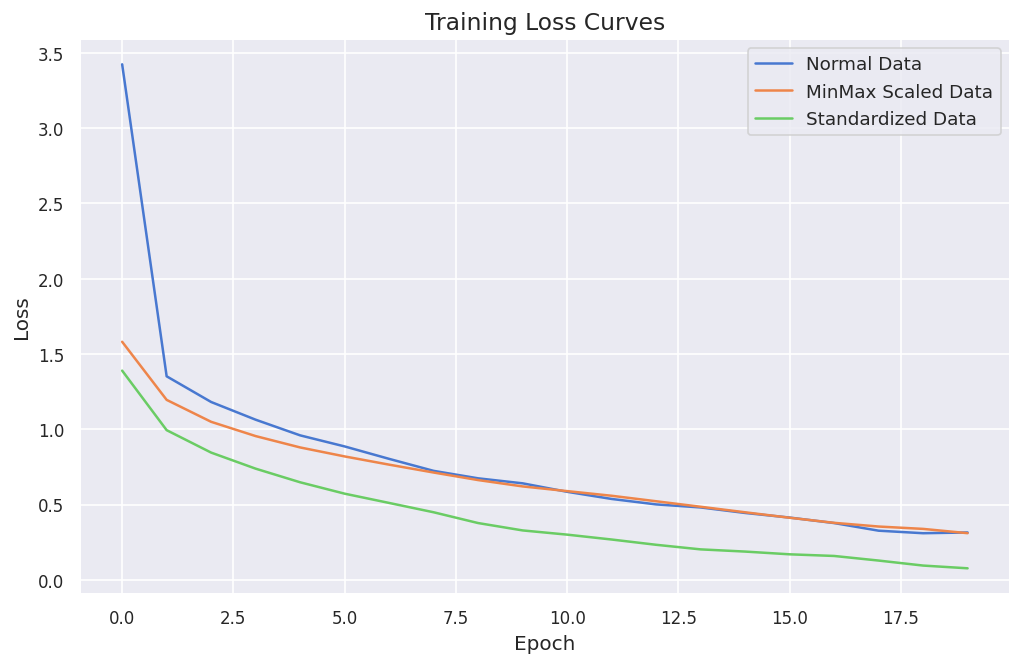

In [39]:
# Plots
histories = [history, history_minMax, history_standard]
labels = ['Normal Data', 'MinMax Scaled Data', 'Standardized Data']

# Loss Plots
plot_curves(histories, labels, metric='loss', title='Training Loss Curves', ylabel='Loss')



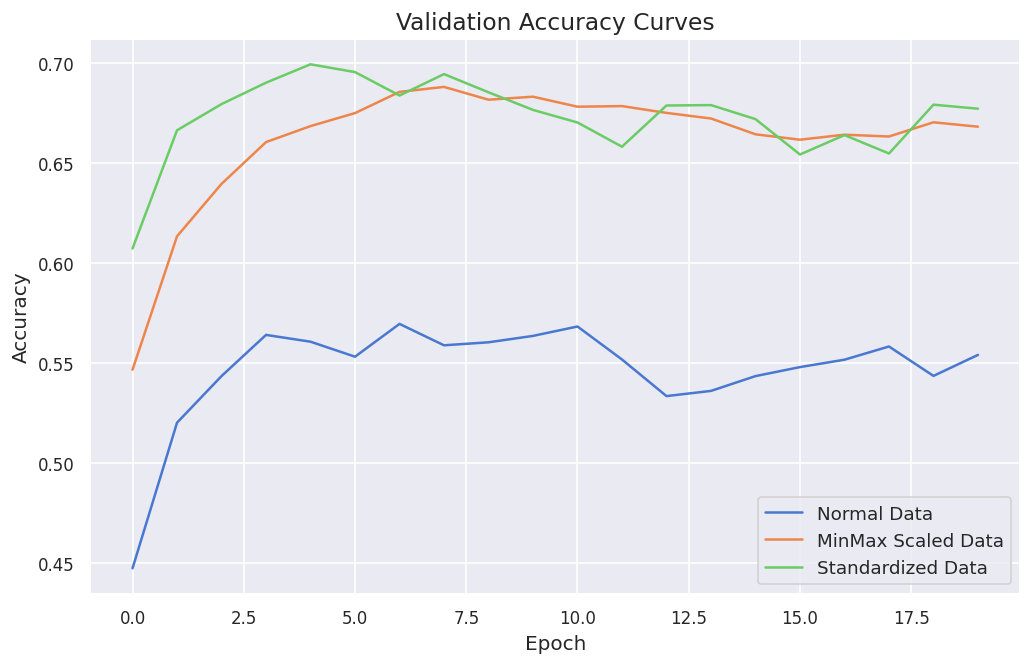

In [40]:
# Accuracy plots
plot_curves(histories, labels, title='Validation Accuracy Curves', ylabel='Accuracy')

In [41]:
# Generating table
import pandas as pd
Data = {"Train Acc": [history.history['accuracy'][-1], history_minMax.history['accuracy'][-1], history_standard.history['accuracy'][-1]],
        "Val Acc" : [history.history['val_accuracy'][-1], history_minMax.history['val_accuracy'][-1], history_standard.history['val_accuracy'][-1]],
        "Test Acc": [test_acc, test_acc_minMax, test_acc_standard],
        "Loss @ epoch 1": [history.history['loss'][0], history_minMax.history['loss'][0], history_standard.history['loss'][0]]}
index = ["None [0-255]", "MinMax [0,1]", "Standardized"]
df = pd.DataFrame(Data, index=index)
df

,Train Acc,Val Acc,Test Acc,Loss @ epoch 1
None [0-255],0.896400,0.5541,0.5467,3.424636
"MinMax [0,1]",0.894075,0.6682,0.6621,1.581232
Standardized,0.975075,0.6772,0.6737,1.389482


In [42]:
def Augmented():
  datagen = tf.keras.preprocessing.image.ImageDataGenerator(
  rotation_range=15,
  width_shift_range=0.1,
  height_shift_range=0.1,
  horizontal_flip=True,
  zoom_range=0.1
  )
  datagen.fit(x_train_standard)
  return datagen

In [43]:
# Training with augmented data
model_aug = BaselineCNN()
datagen = Augmented()
augmented_train_generator = datagen.flow(x_train_standard, to_categorical(y_train, 10), batch_size=128)

start_aug = time.time()
history_aug = model_aug.fit(augmented_train_generator,
                            validation_data=(x_val_standard, to_categorical(y_val, 10)),
                            epochs=40,
                            verbose=0)
elapsed_aug = time.time() - start_aug

test_loss_aug, test_acc_aug = model_aug.evaluate(x_test_standard, to_categorical(y_test, 10), verbose=0)
print(f"Test Acc: {test_acc_aug:.4f} | Test Loss: {test_loss_aug:.4f} | Time: {elapsed_aug:.1f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.7734 | Test Loss: 0.7115 | Time: 1000.8s


In [44]:
# Training with standardized data (no augmented)
model = BaselineCNN()
history_non_aug, test_acc_non_aug, test_loss_non_aug, elapsed_non_aug = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test, epochs=40)

Test Acc: 0.6764 | Test Loss: 3.1301 | Time:92.8s


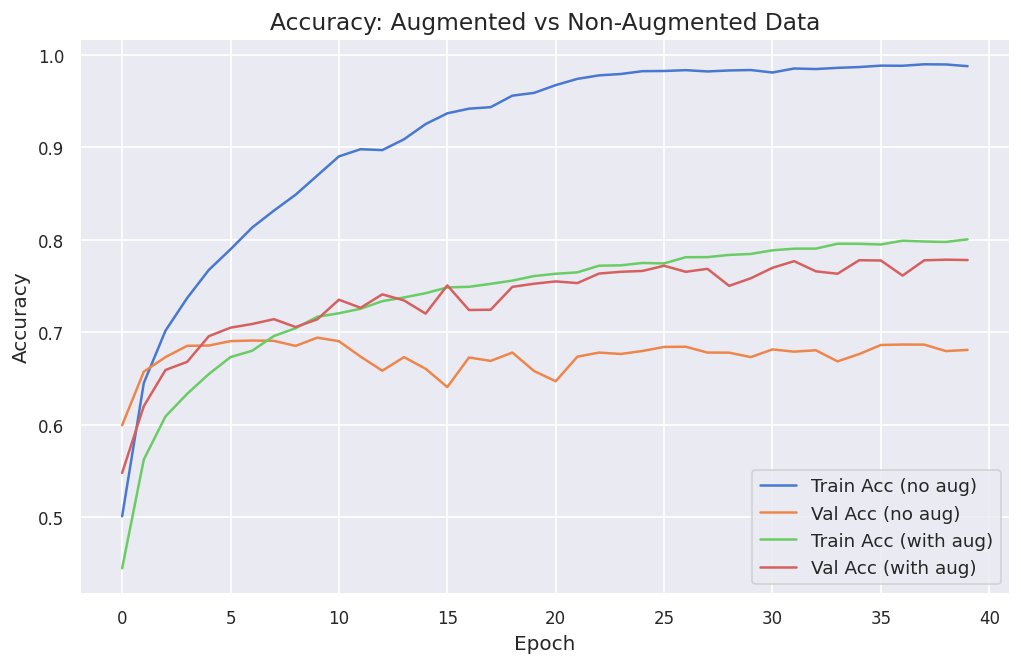

In [45]:
# Plotting 4 curves
plt.figure(figsize=(10, 6))
plt.plot(history_non_aug.history['accuracy'], label='Train Acc (no aug)')
plt.plot(history_non_aug.history['val_accuracy'], label='Val Acc (no aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (with aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (with aug)')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy: Augmented vs Non-Augmented Data')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
# Non-augmented gap
gap_non_aug = history_non_aug.history['accuracy'][39] - history_non_aug.history['val_accuracy'][39]

# Augmented gap
gap_aug = history_aug.history['accuracy'][39] - history_aug.history['val_accuracy'][39]

print(f"Non-Augmented gap at epoch 40: {gap_non_aug:.4f}")
print(f"Augmented gap at epoch 40: {gap_aug:.4f}")
if(gap_non_aug < gap_aug):
  print("Non-Augmented is better")
else:
  print("Augmented is better")

Non-Augmented gap at epoch 40: 0.3066
Augmented gap at epoch 40: 0.0224
Augmented is better


## **Task2 -> build model**

### part A

In [47]:
# Imports
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout

In [48]:
# ── Part A – Width Experiment ─────────────────────────────────────────────
# Build and train three CNN variants with increasing filter widths
# (small: 8/16, medium: 16/32, large: 24/48 filters per block).
# Each model has two Conv blocks followed by a Flatten + Dense head.


partA_models = []
for i in range(1,4):
    model = Sequential([
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')
    ])

    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val))
    partA_models.append(model)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,055,698 (4.03 MB)

 Trainable params: 1,055,698 (4.03 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_70 (Conv2D)              │ (None, 32, 32, 24)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 32, 32, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 16, 16, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,185,634 (12.15 MB)

 Trainable params: 3,185,634 (12.15 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3628 - loss: 3.3876 - val_accuracy: 0.4527 - val_loss: 1.5432
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5050 - loss: 1.3726 - val_accuracy: 0.4904 - val_loss: 1.4378
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5906 - loss: 1.1554 - val_accuracy: 0.5044 - val_loss: 1.3970
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6497 - loss: 0.9908 - val_accuracy: 0.4978 - val_loss: 1.4725
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7027 - loss: 0.8408 - val_accuracy: 0.4961 - val_loss: 1.5961
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7678 - loss: 0.6612 - val_accuracy: 0.4915 - val_loss: 1.9092
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8112 - loss: 0.5393 - val_accuracy: 0.5004 - val_loss: 2.1954
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8451 - loss: 0.4486 - va

In [49]:
# ── Part A – Evaluate Accuracy ───────────────────────────────────────────
# Run inference on the test set for each Part-A model and record accuracy.

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracy_scores = []
name_models = ['small','medium','large']
for i,model in enumerate(partA_models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


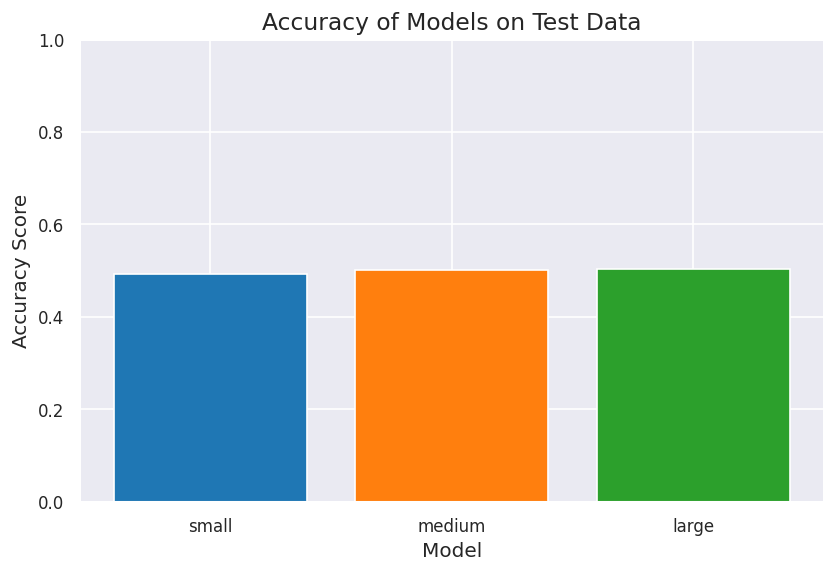

In [50]:
# ── Part A – Visualise Results ───────────────────────────────────────────
# Plot a bar chart comparing the test accuracy of the three CNN widths.

# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.show()

### Part C

In [51]:
# ── Part C – Depth & Pooling Experiment ──────────────────────────────────
# Define three CNN architectures that explore increasing depth and the
# effect of Global Average Pooling (GAP) as a replacement for Flatten.
#   Model 1: 2 Conv blocks + Flatten (baseline)
#   Model 2: 3 Conv blocks + 1× GAP
#   Model 3: 4 Conv blocks + 2× GAP

from tensorflow.keras.layers import GlobalAveragePooling2D
partC_models = [
    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')])
    ]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
# ── Part C – Compile & Train ──────────────────────────────────────────────
# Compile all Part-C models with Adam + sparse categorical cross-entropy
# and train for 20 epochs; store each training history for later analysis.

history = []
for i,model in enumerate(partC_models):
    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    history.append(model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val)))

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,128,618 (8.12 MB)

 Trainable params: 2,128,618 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_84 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.3320 - loss: 1.7623 - val_accuracy: 0.4446 - val_loss: 1.4772
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5148 - loss: 1.3243 - val_accuracy: 0.5714 - val_loss: 1.1611
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5985 - loss: 1.1166 - val_accuracy: 0.6270 - val_loss: 1.0423
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6428 - loss: 1.0031 - val_accuracy: 0.6490 - val_loss: 0.9931
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6737 - loss: 0.9198 - val_accuracy: 0.6574 - val_loss: 0.9904
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6977 - loss: 0.8537 - val_accuracy: 0.6760 - val_loss: 0.9288
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7231 - loss: 0.7884 - val_accuracy: 0.6913 - val_loss: 0.8980
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7381 - loss: 0.7427 - va

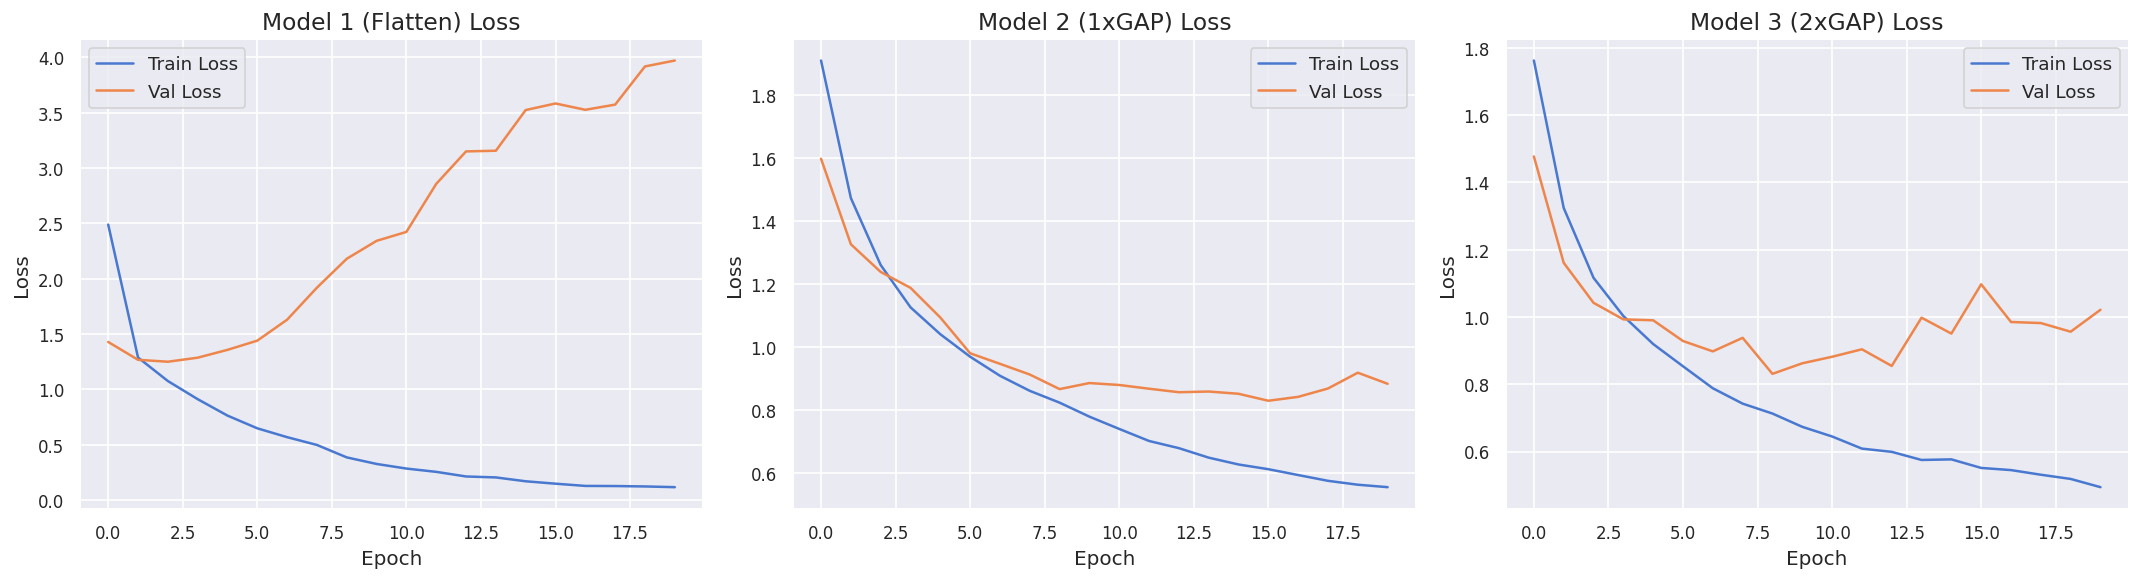

In [53]:
# ── Part C – Training / Validation Loss Curves ───────────────────────────
# Plot side-by-side loss curves (train vs. val) for all three Part-C models
# to inspect overfitting behaviour as depth increases.

# Depth loss Comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
model_names = ['Model 1 (Flatten)', 'Model 2 (1xGAP)', 'Model 3 (2xGAP)']

for i, h in enumerate(history):
    axs[i].plot(h.history['loss'], label='Train Loss')
    axs[i].plot(h.history['val_loss'], label='Val Loss')
    axs[i].set_title(f'{model_names[i]} Loss')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Loss')
    axs[i].legend()

plt.tight_layout()
plt.show()

In [54]:
# ── Part C – Evaluate Test Accuracy ──────────────────────────────────────
# Compute and print the test-set accuracy for each Part-C model.

from sklearn.metrics import accuracy_score

accuracy_scores = []
for i, model in enumerate(partC_models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test.flatten(), y_pred)
    accuracy_scores.append(accuracy)
    print(f"Model {i+1} Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model 1 Accuracy: 0.5494
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Model 2 Accuracy: 0.7003
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Model 3 Accuracy: 0.6871


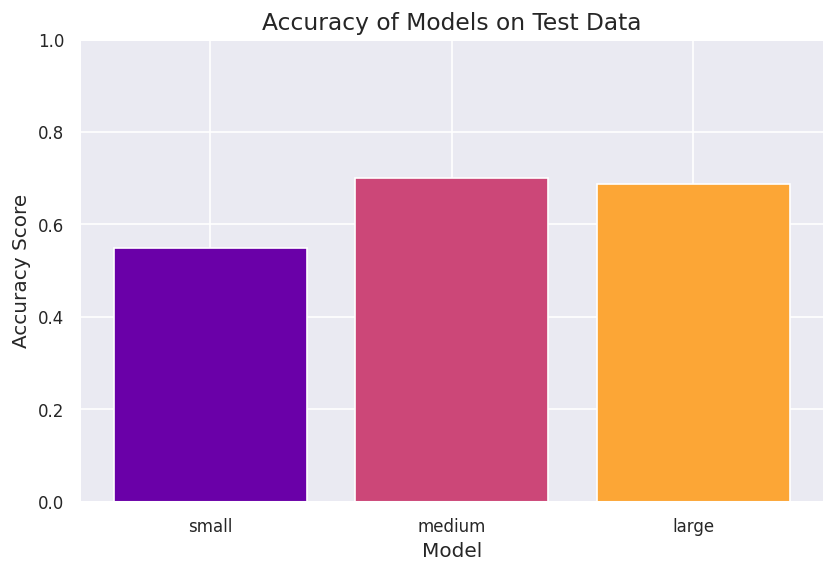

In [55]:
# ── Part C – Visualise Accuracy Comparison ───────────────────────────────
# Bar chart comparing the test accuracy of the three depth/pooling variants.

# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(name_models))))
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()

# Task 3 -> Regularization

### Part A

In [56]:
# No dropout (D0)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc = history.history['accuracy'][29]
val_acc = history.history['val_accuracy'][29]
gap = train_acc - val_acc
_, test_acc = model.evaluate(x_test, y_test, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_92 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4223 - loss: 3.6790 - val_accuracy: 0.5275 - val_loss: 1.3582
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5751 - loss: 1.1998 - val_accuracy: 0.5718 - val_loss: 1.2339
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6549 - loss: 0.9856 - val_accuracy: 0.5856 - val_loss: 1.2093
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7136 - loss: 0.8202 - val_accuracy: 0.5677 - val_loss: 1.3249
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7554 - loss: 0.6930 - val_accuracy: 0.5753 - val_loss: 1.3889
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7935 - loss: 0.5923 - val_accuracy: 0.5684 - val_loss: 1.5425
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8307 - loss: 0.4866 - val_accuracy: 0.5406 - val_loss: 1.8878
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8612 - loss: 0.4013 - va

In [57]:
# After maxpool, rate = 0.25  (D1)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dropout(0.25),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_025 = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc_025 = history_025.history['accuracy'][29]
val_acc_025 = history_025.history['val_accuracy'][29]
gap_025 = train_acc_025 - val_acc_025
_, test_acc_025 = model.evaluate(x_test, y_test, verbose=0)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_96 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1548 - loss: 3.3285 - val_accuracy: 0.2401 - val_loss: 2.0393
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3247 - loss: 1.8516 - val_accuracy: 0.4249 - val_loss: 1.6124
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4445 - loss: 1.5331 - val_accuracy: 0.5063 - val_loss: 1.3689
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5218 - loss: 1.3309 - val_accuracy: 0.5646 - val_loss: 1.2253
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5753 - loss: 1.1891 - val_accuracy: 0.5899 - val_loss: 1.1514
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6204 - loss: 1.0668 - val_accuracy: 0.6087 - val_loss: 1.1045
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6502 - loss: 0.9804 - val_accuracy: 0.6250 - val_loss: 1.0741
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6824 - loss: 0.8915 - va

In [58]:
# After maxpool, rate = 0.5  (D2)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.5),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dropout(0.5),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_05 = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc_05 = history_05.history['accuracy'][29]
val_acc_05 = history_05.history['val_accuracy'][29]
gap_05 = train_acc_05 - val_acc_05
_, test_acc_05 = model.evaluate(x_test, y_test, verbose=0)

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_100 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.1261 - loss: 3.2722 - val_accuracy: 0.2449 - val_loss: 2.0157
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3458 - loss: 1.7989 - val_accuracy: 0.4035 - val_loss: 1.6344
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4202 - loss: 1.5908 - val_accuracy: 0.4631 - val_loss: 1.4829
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4726 - loss: 1.4578 - val_accuracy: 0.5112 - val_loss: 1.3684
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5123 - loss: 1.3501 - val_accuracy: 0.5615 - val_loss: 1.2387
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5543 - loss: 1.2427 - val_accuracy: 0.5865 - val_loss: 1.1612
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5856 - loss: 1.1622 - val_accuracy: 0.6203 - val_loss: 1.0894
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6122 - loss: 1.0839 - va

In [59]:
data = {"Train Acc" : [history.history['accuracy'][-1], history_025.history['accuracy'][-1], history_05.history['accuracy'][-1]],
        "Val Acc"   : [history.history['val_accuracy'][-1], history_025.history['val_accuracy'][-1], history_05.history['val_accuracy'][-1]],
        "Test Acc"  : [test_acc, test_acc_025, test_acc_05],
        "Overfit Gap": [gap, gap_025, gap_05]}
index = ["D0", "D1", "D2"]
df = pd.DataFrame(data, index=index)
df

,Train Acc,Val Acc,Test Acc,Overfit Gap
D0,0.978300,0.5593,0.5613,0.419000
D1,0.944925,0.6413,0.6414,0.303625
D2,0.874500,0.6959,0.6852,0.178600


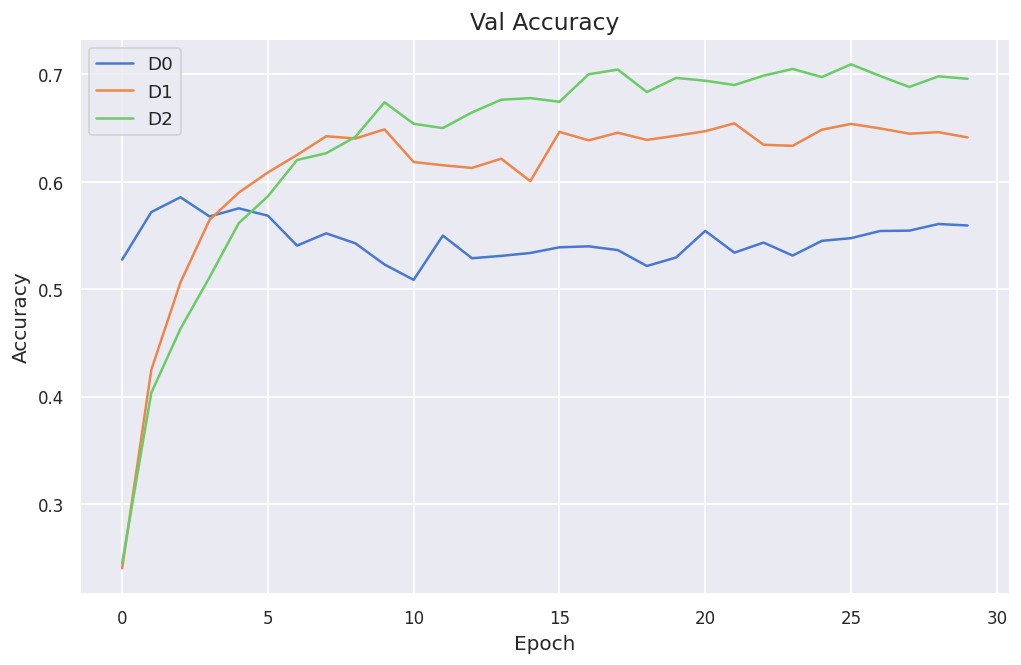

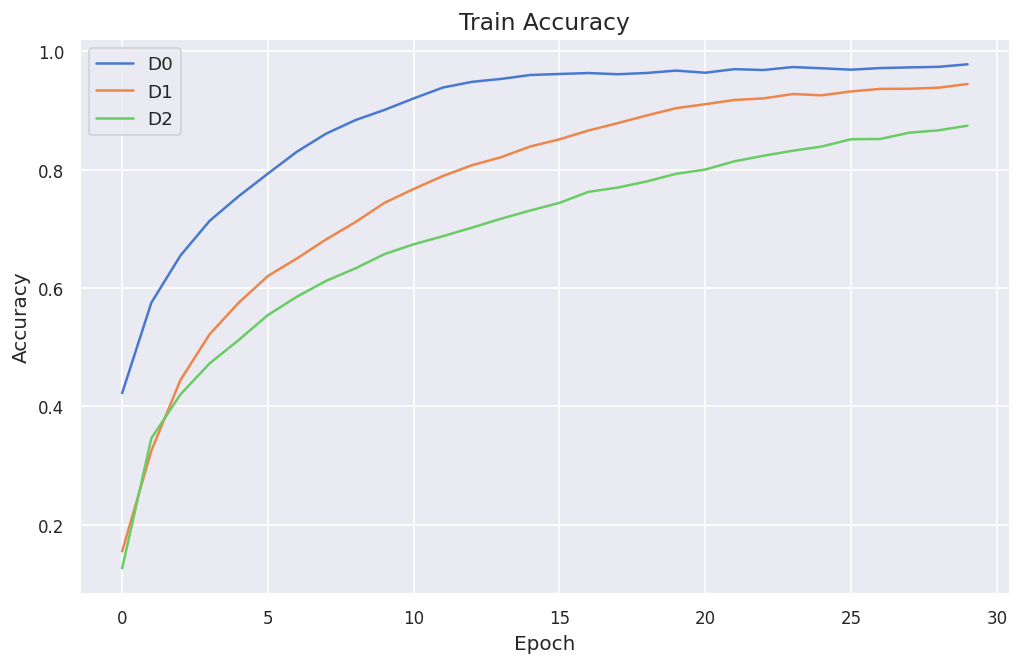

In [60]:
histories = [history, history_025, history_05]
labels = ['D0', 'D1', 'D2']
plot_curves(histories, labels, title='Val Accuracy', ylabel='Accuracy')
plot_curves(histories, labels,metric = 'accuracy', title='Train Accuracy', ylabel='Accuracy')

In [61]:
min_gap = min([gap, gap_025, gap_05])
if min_gap == gap:
  print("D0 is best")
elif min_gap == gap_025:
  print("D1 is best")
else:
  print("D2 is best")

D2 is best


### Part B

In [62]:
# ES0 No early stopping
start = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val))
_, test_acc = model.evaluate(x_test, y_test, verbose=0)
elapsed = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_104 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4187 - loss: 2.1480 - val_accuracy: 0.5234 - val_loss: 1.3228
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5829 - loss: 1.1695 - val_accuracy: 0.5913 - val_loss: 1.1864
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6735 - loss: 0.9317 - val_accuracy: 0.5805 - val_loss: 1.2432
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7434 - loss: 0.7333 - val_accuracy: 0.5800 - val_loss: 1.3094
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7974 - loss: 0.5821 - val_accuracy: 0.5663 - val_loss: 1.6882
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8383 - loss: 0.4650 - val_accuracy: 0.5561 - val_loss: 1.8837
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8666 - loss: 0.3866 - val_accuracy: 0.5227 - val_loss: 2.0827
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8960 - loss: 0.3053 - va

In [63]:
# ES2
start_es2 = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])
es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_es2 = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val), callbacks=[es])
_, test_acc_es2 = model.evaluate(x_test, y_test, verbose=0)
elapsed_es2 = time.time() - start_es2

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_108 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3950 - loss: 2.9022 - val_accuracy: 0.4616 - val_loss: 1.5213
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5536 - loss: 1.2546 - val_accuracy: 0.5511 - val_loss: 1.2849
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6432 - loss: 1.0204 - val_accuracy: 0.5812 - val_loss: 1.2221
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6991 - loss: 0.8632 - val_accuracy: 0.5926 - val_loss: 1.2988
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7402 - loss: 0.7453 - val_accuracy: 0.5724 - val_loss: 1.3746
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7863 - loss: 0.6112 - val_accuracy: 0.5328 - val_loss: 1.6359
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8297 - loss: 0.4952 - val_accuracy: 0.5538 - val_loss: 1.6997
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8645 - loss: 0.3944 - va

In [64]:
# ES3
start_es3 = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])
es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights = True)
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_es3 = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val), callbacks = [es])
_, test_acc_es3 = model.evaluate(x_test, y_test, verbose=0)
elapsed_es3 = time.time() - start_es3

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_112 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3661 - loss: 2.6409 - val_accuracy: 0.4628 - val_loss: 1.4813
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5171 - loss: 1.3569 - val_accuracy: 0.5287 - val_loss: 1.3233
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6058 - loss: 1.1162 - val_accuracy: 0.5581 - val_loss: 1.2728
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6673 - loss: 0.9429 - val_accuracy: 0.5409 - val_loss: 1.3841
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7282 - loss: 0.7776 - val_accuracy: 0.5442 - val_loss: 1.4711
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7671 - loss: 0.6670 - val_accuracy: 0.5666 - val_loss: 1.5980
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8114 - loss: 0.5415 - val_accuracy: 0.5443 - val_loss: 1.9242
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8436 - loss: 0.4503 - va

In [65]:
loss_es0 = []
for i in history.history['val_loss']:
  loss_es0.append(i)
min_es0 = min(loss_es0)

loss_es2 = []
for i in history_es2.history['val_loss']:
  loss_es2.append(i)
min_es2 = min(loss_es2)

loss_es3 = []
for i in history_es3.history['val_loss']:
  loss_es3.append(i)
min_es3 = min(loss_es3)

In [66]:
import pandas as pd
data = {"Stopped at epoch": [len(history.history['loss']), len(history_es2.history['loss']), len(history_es3.history['loss'])],
        "Best Val loss"   : [min_es0, min_es2, min_es3],
        "Test_Acc"        : [test_acc, test_acc_es2, test_acc_es3],
        "Time(s)"         : [elapsed, elapsed_es2, elapsed_es3]}
index = ["ES0", "ES2", "ES3"]
df = pd.DataFrame(data, index=index)
df


,Stopped at epoch,Best Val loss,Test_Acc,Time(s)
ES0,50,1.186365,0.5805,209.271572
ES2,8,1.222105,0.5741,42.866542
ES3,13,1.272793,0.5645,61.844786


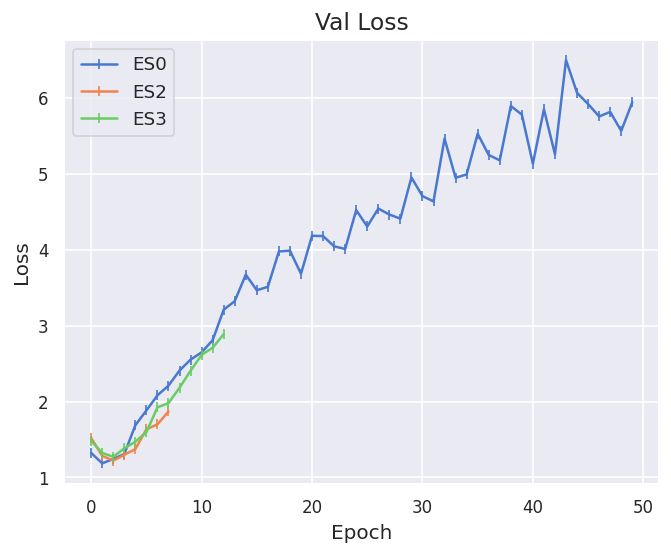

In [67]:
histories = [history, history_es2, history_es3]
labels = ['ES0', 'ES2', 'ES3']
# plot_curves(histories, labels, metric = 'val_loss', title='Val Loss', ylabel='Accuracy')
plt.plot(history.history['val_loss'], label='ES0', marker = '|')
plt.plot(history_es2.history['val_loss'], label='ES2', marker = '|')
plt.plot(history_es3.history['val_loss'], label='ES3', marker = '|')
plt.title('Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [73]:
print("From the results:")
print("patience=5 is really aggresive as it stops too early")
print("patience=10 is not too lenient,as it doesn't stop too late")

From the results:
patience=5 is really aggresive as it stops too early
patience=10 is not too lenient,as it doesn't stop too late


# **Task4 -> Optimizers**
### Part A



In [69]:
# ── Part D – Optimizer Experiment (Setup) ────────────────────────────────
# Define a dictionary of optimizers to compare:
# SGD, SGD+Momentum, AdaGrad, RMSProp, and Adam — all at the same LR.

# Define optimizer factories to avoid reusing optimizer objects across different models
optimizer_factories = {
    'SGD':keras.optimizers.SGD(learning_rate=0.001),
    'Momentum':keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad':keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp':keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':keras.optimizers.Adam(learning_rate=0.001),
}


--- Training with Optimizer: SGD ---
Test Acc: 0.5711 | Test Loss: 1.2349 | Time:79.4s

--- Training with Optimizer: Momentum ---
Test Acc: 0.6485 | Test Loss: 2.8718 | Time:81.3s

--- Training with Optimizer: AdaGrad ---
Test Acc: 0.6570 | Test Loss: 3.2891 | Time:80.9s

--- Training with Optimizer: RMSProp ---
Test Acc: 0.6391 | Test Loss: 4.7828 | Time:84.2s

--- Training with Optimizer: Adam ---
Test Acc: 0.6347 | Test Loss: 4.3605 | Time:85.6s


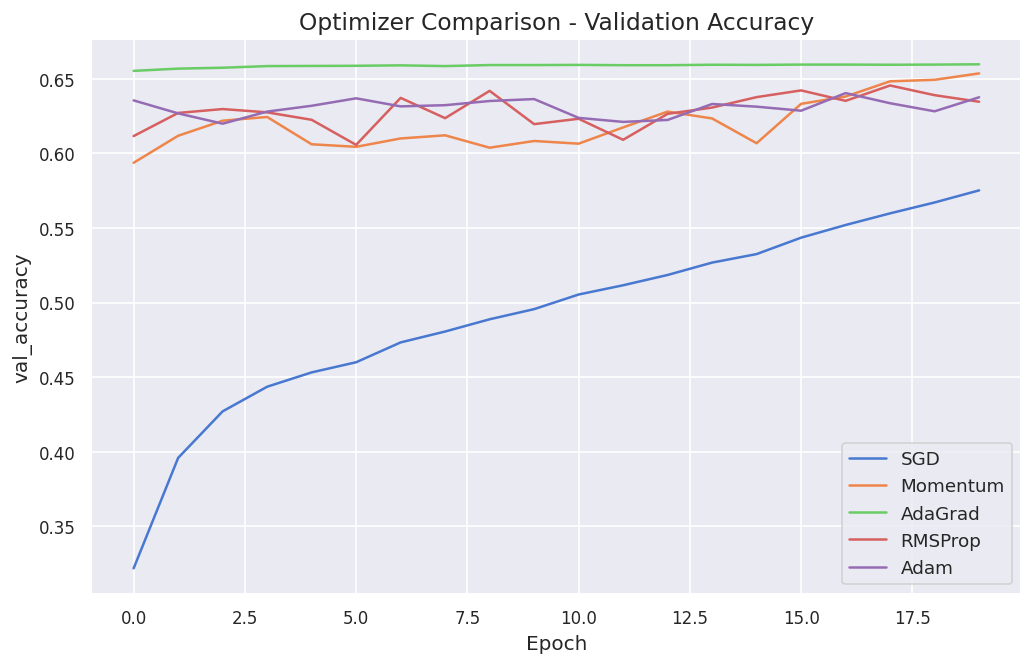

In [70]:
# ── Part D – Train with Different Optimizers ─────────────────────────────
# Re-build the medium CNN architecture and train one copy per optimizer.
# Results (accuracy, loss, time) are stored for comparison.

medium_model_base = Sequential([
    layers.Input(shape=(32, 32, 3)),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation='softmax')
])

results = {}

for opt_name, optimizer in optimizer_factories.items():
    print(f"\n--- Training with Optimizer: {opt_name} ---")
    model = medium_model_base

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'],
                  )

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train, y_train, x_val, y_val, x_test, y_test,
        epochs=20, batch_size=128
    )
    results[opt_name] = history

# Plot all curves together for comparison
plot_curves(list(results.values()), list(results.keys()), title='Optimizer Comparison - Validation Accuracy')

## Part B

Learning Rate: 0.0001 for Adam optimizer
Test Acc: 0.6570 | Test Loss: 4.9084 | Time:122.6s
Learning Rate: 0.001 for Adam optimizer
Test Acc: 0.6289 | Test Loss: 6.2980 | Time:121.3s
Learning Rate: 0.01 for Adam optimizer
Test Acc: 0.1000 | Test Loss: 2.3032 | Time:119.6s


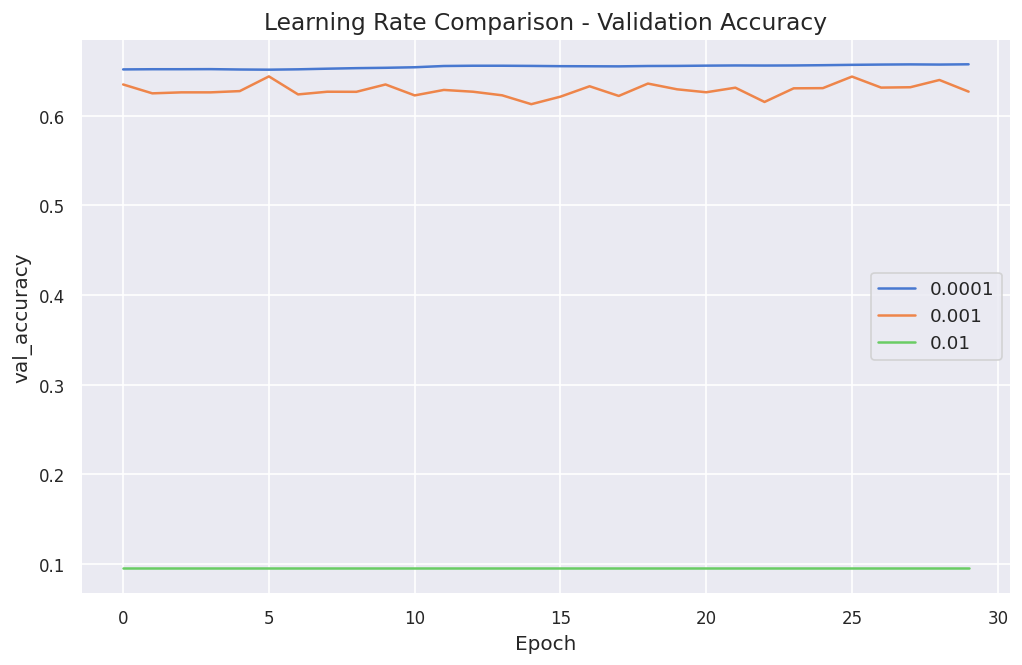

In [71]:
# ── Part D – Learning-Rate Sweep (Adam) ──────────────────────────────────
# Train the medium CNN with Adam at three learning rates
# (0.0001, 0.001, 0.01) to study the effect on convergence.

learning_rates = [0.0001,0.001,0.01]
results = {}

for i in learning_rates:
  print(f"Learning Rate: {i} for Adam optimizer")
  model = medium_model_base
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=i),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'],
                )

  history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train, y_train, x_val, y_val, x_test, y_test,
        epochs=30, batch_size=128
    )
  results[i] = history

plot_curves(list(results.values()), list(results.keys()), title='Learning Rate Comparison - Validation Accuracy')